# TNG300 descendant mass: out-of-sample predictive performance

既存の z≈8 カタログから、$10.8<\log_{10}(M_8/M_\odot)<11.2$ の初期FoF haloについて、$\log_{10}(M_{200c,\mathrm{host}}(z=0)/M_\odot)$ と $P(M_0\geq10^{14}M_\odot)$ を予測する。

**testは最終評価まで使わない。** 最終ホスト単位で分割し、特徴量・半径・学習器はtraining内のGroupKFoldで選択する。SubLink、粒子読み込み、環境再計算は行わない。すべてのモデルに同じtest個体を使用する。

初期ハロー質量も直接のJWST observableではないためidealized inferenceである。Nhaloを使うD/Fはsimulation-only benchmark。Group分割でも異なる最終ホスト間の空間相関は除去できない。独立宇宙体積への汎化は本解析の検証範囲外。

In [1]:
from pathlib import Path
import os, json, hashlib, platform, time, warnings
from collections import OrderedDict
import numpy as np
import pandas as pd
import scipy
from scipy.stats import spearmanr
import sklearn
from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             brier_score_loss, log_loss, roc_auc_score,
                             precision_recall_curve, auc, average_precision_score)
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

cwd = Path.cwd().resolve()
PROTO_ROOT = next((p / 'protohalo' for p in [cwd, *cwd.parents]
                   if (p / 'protohalo' / 'notebooks').is_dir()), None)
if PROTO_ROOT is None:
    PROTO_ROOT = next((p for p in [cwd, *cwd.parents]
                       if (p / 'notebooks').is_dir() and (p / 'data').is_dir()), None)
if PROTO_ROOT is None:
    raise FileNotFoundError('Set PROTO_ROOT to this repository/protohalo.')
DESCENDANT_PATH = PROTO_ROOT / 'data/tng300_z8_M11_descendants.csv'
ENVIRONMENT_PATH = PROTO_ROOT / 'data/tng300_z8_M11_descendants_environment.csv'
OUTPUT_DIR = PROTO_ROOT / 'analysis_summary/descendant_predictive_performance'
RANDOM_SEED = 42
TEST_SIZE = 0.2
CV_FOLDS = 3
BOOTSTRAP_N = 500
RADII = [1, 2, 3, 5, 8, 10, 15, 20]
RF_TREES = 80
N_JOBS = 2
CALIBRATION_EDGES = np.linspace(0, 1, 9)
RUN_UNIQUE_DESCENDANT = True
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.grid': False})
START_TIME = time.time()


## 保存カタログの確認

主解析5冊は参照用で変更しない。実際の銀河量は `MstarCentral_z8` / `SFRCentral_z8`、球環境量は `Ngal_R*` / `Nhalo_R*`。銀河数は恒星質量 >10⁸ M☉、ハロー数は M200c >10⁹⋅⁵ M☉、半径はcMpc、対象を除く。保存環境カタログの定義をそのまま使用する。

対数恒星質量は正値のみ計算し、非正値・非有限値は欠損としてtraining中央値で補完する。SFR=0は有効なゼロ、負値・非有限値は欠損とする。raw SFR・countを使い、標準化と欠損補完は各training fold内のPipelineでfitする。IDと目的変数が有効なサンプルを全モデルで共有する。

In [2]:
reference_names = ['tng300_z8_descendant_mass', 'tng300_descendant_with_galaxy_properties',
                   'tng300_descendant_with_environment', 'tng300_environment_robustness',
                   'tng300_main_results_summary']
for name in reference_names:
    path = PROTO_ROOT / 'notebooks' / (name + '.ipynb')
    if not path.is_file():
        raise FileNotFoundError(f'Reference notebook missing: {path}')
for path in [DESCENDANT_PATH, ENVIRONMENT_PATH]:
    if not path.is_file():
        raise FileNotFoundError(f'Required real catalog missing: {path}; no synthetic replacement used.')
desc = pd.read_csv(DESCENDANT_PATH)
env = pd.read_csv(ENVIRONMENT_PATH)
ids = ['GroupID_z8', 'SubhaloID_z8', 'GroupID_z0', 'logM200c_z8', 'logM200c_z0']
required = ids + ['MstarCentral_z8', 'SFRCentral_z8'] + [f'{t}_R{r}' for t in ['Ngal', 'Nhalo'] for r in RADII]
for frame, cols, path in [(desc, ids, DESCENDANT_PATH), (env, required, ENVIRONMENT_PATH)]:
    missing = sorted(set(cols) - set(frame.columns))
    if missing: raise ValueError(f'{path}: missing columns {missing}')
    if frame.GroupID_z8.duplicated().any(): raise ValueError(f'{path}: duplicate GroupID_z8')
joined = desc[ids].merge(env[required], on='GroupID_z8', how='left',
                          suffixes=('_base', ''), validate='one_to_one', indicator=True)
if not joined['_merge'].eq('both').all():
    raise ValueError('Environment data missing for some baseline halos; supply complete environment CSV.')
for col in ids[1:]:
    if not np.allclose(joined[col], joined[col + '_base'], equal_nan=True, atol=1e-8, rtol=0):
        raise ValueError(f'Catalog mismatch: {col}')
valid = joined.logM200c_z8.gt(10.8) & joined.logM200c_z8.lt(11.2)
for col in ids: valid &= np.isfinite(joined[col])
valid &= joined.GroupID_z0.ge(0) & joined.GroupID_z8.ge(0)
data = joined.loc[valid, required].copy().reset_index(drop=True)
for col in ['GroupID_z8', 'GroupID_z0', 'SubhaloID_z8']:
    assert np.all(data[col] == np.floor(data[col]))
    data[col] = data[col].astype(np.int64)
mstar = data.MstarCentral_z8.to_numpy(float)
data['logMstar'] = np.log10(np.where(np.isfinite(mstar) & (mstar > 0), mstar, np.nan))
data['SFR'] = data.SFRCentral_z8.where(np.isfinite(data.SFRCentral_z8) & data.SFRCentral_z8.ge(0))
for col in [f'{t}_R{r}' for t in ['Ngal', 'Nhalo'] for r in RADII]:
    data[col] = data[col].where(np.isfinite(data[col]) & data[col].ge(0))
data['cluster'] = data.logM200c_z0.ge(14).astype(int)
print(f'Baseline rows={len(desc):,}; retained={len(data):,}; excluded={len(desc)-len(data):,}')
print('Missing galaxy values:', data[['logMstar', 'SFR']].isna().sum().to_dict())
display(data[ids].head())


Baseline rows=3,099; retained=3,099; excluded=0
Missing galaxy values: {'logMstar': 1, 'SFR': 0}


,GroupID_z8,SubhaloID_z8,GroupID_z0,logM200c_z8,logM200c_z0
0,36,494,1,11.152069,15.116389
1,40,537,128,11.197676,14.224381
2,65,747,8,11.100756,14.600158
3,77,846,332,11.154643,13.998933
4,80,867,473,11.166055,13.908890


## 分割とモデル選択（testはここでは評価しない）

A: 初期質量、B: +中心銀河の恒星質量/SFR、C: +Ngal、D: +Nhalo、E: +銀河特性/Ngal、F: +銀河特性/Nhalo。

回帰はDummy(mean)、Linear、制限付きRF、分類はDummy(prior)、Logistic、制限付きRFを比較する。各feature set・学習器について全半径をtraining CVで評価する。最終的な学習器もCVで選び、回帰と分類で独立の半径を許す。図の誤差棒はfold標準偏差で、最良CV値の選択バイアスを除去したCIではない。汎化の評価には最後のtestを用いる。

補助的なunique-descendant sampleは同じホスト分割を使い、各最終ホストにつき最もmassiveな初期ハローを残して再学習・再選択する。これは最終状態による事後選択であり、観測selectionではない。

In [3]:
groups = data.GroupID_z0.to_numpy()
splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_SEED)
train_idx, test_idx = next(splitter.split(data, groups=groups))
train_hosts = set(groups[train_idx]); test_hosts = set(groups[test_idx])
assert train_hosts.isdisjoint(test_hosts)
splits = {'halo_level': (data.iloc[train_idx].copy(), data.iloc[test_idx].copy())}
if RUN_UNIQUE_DESCENDANT:
    unique = data.sort_values(['logM200c_z8', 'GroupID_z8'], ascending=[False, True]).drop_duplicates('GroupID_z0')
    splits['unique_descendant'] = (unique.loc[unique.GroupID_z0.isin(train_hosts)].copy(),
                                   unique.loc[unique.GroupID_z0.isin(test_hosts)].copy())
print('Host split verified; test host fraction:', len(test_hosts)/len(set(groups)))
for sample, (tr, te) in splits.items():
    print(sample, 'train/test halos:', len(tr), len(te), 'hosts:', tr.GroupID_z0.nunique(), te.GroupID_z0.nunique())

MODEL_NAMES = OrderedDict(A='Baseline', B='Galaxy', C='Galaxy environment', D='Halo environment',
                          E='Galaxy + environment', F='Full simulation')
def feature_columns(key, radius=None):
    cols = ['logM200c_z8']
    if key in ['B', 'E', 'F']: cols += ['logMstar', 'SFR']
    if key in ['C', 'E']: cols += [f'Ngal_R{int(radius)}']
    if key in ['D', 'F']: cols += [f'Nhalo_R{int(radius)}']
    return cols

def pipeline(estimator):
    return Pipeline([('impute', SimpleImputer(strategy='median', add_indicator=True)),
                     ('scale', StandardScaler()), ('model', estimator)])

def candidates(task):
    if task == 'regression':
        out = [('Dummy', pipeline(DummyRegressor(strategy='mean'))),
               ('Linear', pipeline(LinearRegression()))]
        cls = RandomForestRegressor
    else:
        out = [('Dummy', pipeline(DummyClassifier(strategy='prior'))),
               ('Logistic', pipeline(LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_SEED)))]
        cls = RandomForestClassifier
    for depth, leaf in [(6, 10), (None, 30)]:
        out.append((f'RF_depth{depth}_leaf{leaf}', pipeline(cls(n_estimators=RF_TREES,
                     max_depth=depth, min_samples_leaf=leaf, max_features=1.0,
                     random_state=RANDOM_SEED, n_jobs=N_JOBS))))
    return out

cv_records = []
selected = {}
fitted = {}
def train_select(sample, train):
    cv = list(GroupKFold(n_splits=CV_FOLDS).split(train, groups=train.GroupID_z0))
    for it, iv in cv:
        assert set(train.iloc[it].GroupID_z0).isdisjoint(set(train.iloc[iv].GroupID_z0))
        assert train.iloc[it].cluster.nunique() == 2 and train.iloc[iv].cluster.nunique() == 2
    selected[sample] = {}; fitted[sample] = {}
    for key in MODEL_NAMES:
        selected[sample][key] = {}; fitted[sample][key] = {}
        radii = RADII if key in ['C', 'D', 'E', 'F'] else [None]
        for task in ['regression', 'classification']:
            y = train.logM200c_z0.to_numpy() if task == 'regression' else train.cluster.to_numpy()
            best = None
            for radius in radii:
                cols = feature_columns(key, radius)
                assert not train[cols].isna().all().any(), f'All-missing training feature: {cols}'
                for family, estimator in candidates(task):
                    losses = []
                    for fold, (it, iv) in enumerate(cv):
                        est = clone(estimator).fit(train.iloc[it][cols], y[it])
                        pred = est.predict(train.iloc[iv][cols]) if task == 'regression' else est.predict_proba(train.iloc[iv][cols])[:, 1]
                        loss = np.sqrt(mean_squared_error(y[iv], pred)) if task == 'regression' else brier_score_loss(y[iv], pred)
                        losses.append(loss)
                        cv_records.append(dict(sample=sample, model=key, task=task, radius=radius,
                                               family=family, fold=fold, loss=float(loss)))
                    score = float(np.mean(losses))
                    if best is None or score < best['cv_score']:
                        best = dict(radius=radius, features=cols, family=family, cv_score=score,
                                    fold_std=float(np.std(losses, ddof=1)), estimator=estimator)
            est = best.pop('estimator').fit(train[best['features']], y)
            best['hyperparameters'] = est.named_steps['model'].get_params()
            selected[sample][key][task] = best
            fitted[sample][key][task] = est
        print(sample, key, 'selected:', {t:(s['family'],s['radius']) for t,s in selected[sample][key].items()}, flush=True)
    return cv
CV_SPLITS = {sample: train_select(sample, tr) for sample, (tr, _) in splits.items()}
cv_table = pd.DataFrame(cv_records)
cv_table.to_csv(OUTPUT_DIR / 'cv_scores.csv', index=False)


Host split verified; test host fraction: 0.20045428733674048
halo_level train/test halos: 2534 565 hosts: 1408 353
unique_descendant train/test halos: 1408 353 hosts: 1408 353
halo_level A selected: {'regression': ('Linear', None), 'classification': ('Logistic', None)}
halo_level B selected: {'regression': ('Linear', None), 'classification': ('Logistic', None)}
halo_level C selected: {'regression': ('RF_depthNone_leaf30', 15), 'classification': ('Logistic', 15)}
halo_level D selected: {'regression': ('RF_depthNone_leaf30', 10), 'classification': ('Logistic', 10)}
halo_level E selected: {'regression': ('RF_depthNone_leaf30', 15), 'classification': ('Logistic', 15)}
halo_level F selected: {'regression': ('RF_depthNone_leaf30', 10), 'classification': ('Logistic', 10)}
unique_descendant A selected: {'regression': ('Linear', None), 'classification': ('Logistic', None)}
unique_descendant B selected: {'regression': ('Linear', None), 'classification': ('Logistic', None)}
unique_descendant C se

## 条件付き分位点（trainingのみ）

GradientBoostingのquantile lossで $Q_{16},Q_{50},Q_{84}$ を推定する。各feature setの回帰CVで選択した半径を固定し、二つの小さな設定をtraining内のgroup CVの平均pinball lossで選択する。testは調整に使用しない。分位点crossingはtest値を見ずに各予測を昇順に並べ替え、発生率も記録する。

これは $p(M_0\mid M_8,\mathbf X)$ の三つの分位点の近似であり、完全なPDFではない。幅は対数質量のdex単位。coverageと併せて評価する。追加の確率calibrationは実施せず、分類器の生の予測確率をtestで検証する。

In [4]:
QUANTILES = [0.16, 0.50, 0.84]
def pinball(y, q, alpha):
    residual = y - q
    return np.mean(np.maximum(alpha*residual, (alpha-1)*residual))
quantile_cv_rows = []
for sample, (tr, _) in splits.items():
    y = tr.logM200c_z0.to_numpy()
    for key in MODEL_NAMES:
        cols = selected[sample][key]['regression']['features']
        options = []
        for depth, leaf in [(2, 20), (2, 50)]:
            params = dict(n_estimators=100, learning_rate=0.05, max_depth=depth,
                          min_samples_leaf=leaf, random_state=RANDOM_SEED)
            losses = []
            for fold, (it, iv) in enumerate(CV_SPLITS[sample]):
                for alpha in QUANTILES:
                    est = pipeline(GradientBoostingRegressor(loss='quantile', alpha=alpha, **params))
                    est.fit(tr.iloc[it][cols], y[it])
                    loss = pinball(y[iv], est.predict(tr.iloc[iv][cols]), alpha)
                    losses.append(loss)
                    quantile_cv_rows.append(dict(sample=sample, model=key, depth=depth, leaf=leaf,
                                                 fold=fold, alpha=alpha, pinball_loss=loss))
            options.append((np.mean(losses), params))
        score, params = min(options, key=lambda x:x[0])
        fitted[sample][key]['quantile'] = [pipeline(GradientBoostingRegressor(loss='quantile', alpha=a, **params)).fit(tr[cols], y) for a in QUANTILES]
        selected[sample][key]['quantile'] = dict(features=cols, radius=selected[sample][key]['regression']['radius'],
                                                family='GradientBoostingQuantile', hyperparameters=params,
                                                alphas=QUANTILES, cv_pinball=float(score))
pd.DataFrame(quantile_cv_rows).to_csv(OUTPUT_DIR / 'quantile_cv_scores.csv', index=False)
print('All training selections and fits complete. Test evaluation starts in the next cell.')


All training selections and fits complete. Test evaluation starts in the next cell.


## 固定したモデルのtest評価とpaired host bootstrap

RMSE/MAEはdex。PR-AUCはprecision-recall曲線の台形積分（average precisionも別列に保存）。bootstrapではtestホストを復元抽出し、選ばれたホストのすべての初期ハローを含める。同じ抽出を全モデルに共有する。95% percentile CIはtestサンプルの変動を表し、学習・半径選択の再実行による不確実性は含まない。halo-level指標は各初期ハローに等重みで、多数の初期ハローを持つホストほど寄与が大きい。

改善量はAとの差で、正が改善。改善率も同一bootstrapで計算する。

In [5]:
def metrics(y, b, pred, p, q):
    precision, recall, _ = precision_recall_curve(b, p)
    rho = spearmanr(y, pred).correlation if np.ptp(pred) > 0 else np.nan
    return dict(RMSE=np.sqrt(mean_squared_error(y,pred)), MAE=mean_absolute_error(y,pred),
                R2=r2_score(y,pred), Spearman=rho, Brier=brier_score_loss(b,p),
                LogLoss=log_loss(b,p,labels=[0,1]),
                ROC_AUC=roc_auc_score(b,p) if len(np.unique(b))==2 else np.nan,
                PR_AUC=auc(recall,precision), AP=average_precision_score(b,p),
                W68=np.mean(q[:,2]-q[:,0]), Coverage=np.mean((y>=q[:,0]) & (y<=q[:,2])))
all_predictions = {}; summary_rows = []; bootstrap_tables = {}
for sample, (tr, te) in splits.items():
    assert set(tr.GroupID_z0).isdisjoint(set(te.GroupID_z0))
    y = te.logM200c_z0.to_numpy(); b = te.cluster.to_numpy()
    predictions = te[ids].reset_index(drop=True).copy()
    predictions['cluster'] = b
    values = {}; arrays = {}
    for key in MODEL_NAMES:
        reg = selected[sample][key]['regression']; clf = selected[sample][key]['classification']
        pred = fitted[sample][key]['regression'].predict(te[reg['features']])
        p = fitted[sample][key]['classification'].predict_proba(te[clf['features']])[:,1]
        qraw = np.column_stack([est.predict(te[reg['features']]) for est in fitted[sample][key]['quantile']])
        q = np.sort(qraw, axis=1)
        crossing = np.mean(np.any(np.diff(qraw, axis=1)<0, axis=1))
        predictions[f'pred_logM0_{key}'] = pred
        predictions[f'p_cluster_{key}'] = p
        for i, name in enumerate(['Q16', 'Q50', 'Q84']): predictions[f'{name}_{key}'] = q[:,i]
        arrays[key] = (pred,p,q)
        values[key] = metrics(y,b,pred,p,q)
        values[key]['QuantileCrossingFraction'] = crossing
    host_indices = [np.flatnonzero(te.GroupID_z0.to_numpy()==g) for g in np.unique(te.GroupID_z0)]
    rng = np.random.RandomState(RANDOM_SEED)
    boots = {key: [] for key in MODEL_NAMES}
    for replicate in range(BOOTSTRAP_N):
        idx = np.concatenate([host_indices[j] for j in rng.randint(0,len(host_indices),len(host_indices))])
        for key, (pred,p,q) in arrays.items():
            boots[key].append(metrics(y[idx], b[idx], pred[idx], p[idx], q[idx]))
    bootstrap_tables[sample] = {key: pd.DataFrame(v) for key,v in boots.items()}
    base_boot = bootstrap_tables[sample]['A']
    for key in MODEL_NAMES:
        row = dict(sample=sample, model=key, label=MODEL_NAMES[key], N_test=len(te),
                   N_test_hosts=te.GroupID_z0.nunique(), **values[key],
                   regression_family=selected[sample][key]['regression']['family'],
                   classification_family=selected[sample][key]['classification']['family'],
                   regression_radius=selected[sample][key]['regression']['radius'],
                   classification_radius=selected[sample][key]['classification']['radius'])
        for metric in ['RMSE','MAE','R2','Spearman','Brier','LogLoss','ROC_AUC','PR_AUC','AP','W68','Coverage']:
            ci = np.nanpercentile(bootstrap_tables[sample][key][metric], [2.5,97.5])
            row[metric+'_lo'], row[metric+'_hi'] = ci
        for metric in ['RMSE','Brier']:
            delta = base_boot[metric] - bootstrap_tables[sample][key][metric]
            row['Delta_'+metric] = values['A'][metric]-values[key][metric]
            row['Delta_'+metric+'_lo'], row['Delta_'+metric+'_hi'] = np.percentile(delta,[2.5,97.5])
            row[metric+'_improvement_pct'] = 100*row['Delta_'+metric]/values['A'][metric]
            ci = np.percentile(100*delta/base_boot[metric], [2.5,97.5])
            row[metric+'_improvement_pct_lo'], row[metric+'_improvement_pct_hi'] = ci
        summary_rows.append(row)
    all_predictions[sample] = predictions
    predictions.to_csv(OUTPUT_DIR / ('test_predictions.csv' if sample=='halo_level' else 'test_predictions_unique_descendant.csv'), index=False)
comparison = pd.DataFrame(summary_rows)
comparison.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)
display(comparison[['sample','model','regression_radius','classification_radius','RMSE','Brier','W68','Coverage']])


,sample,model,regression_radius,classification_radius,RMSE,Brier,W68,Coverage
0,halo_level,A,NaN,NaN,0.629387,0.217187,1.395275,0.715044
1,halo_level,B,NaN,NaN,0.629083,0.215978,1.379190,0.692035
2,halo_level,C,15.0,15.0,0.530689,0.153713,0.996478,0.670796
3,halo_level,D,10.0,10.0,0.415665,0.117368,0.709667,0.693805
4,halo_level,E,15.0,15.0,0.529683,0.152966,0.995107,0.661947
5,halo_level,F,10.0,10.0,0.416888,0.116658,0.708652,0.690265
6,unique_descendant,A,NaN,NaN,0.541619,0.105164,1.106171,0.685552
7,unique_descendant,B,NaN,NaN,0.540557,0.104429,1.106379,0.682720
8,unique_descendant,C,8.0,10.0,0.506638,0.088715,0.888297,0.606232
9,unique_descendant,D,8.0,10.0,0.373878,0.068258,0.633882,0.640227


### 学習器ごとの補助比較

Dummy / Linear・Logistic / RFのtest成績も保存する。各学習器の半径とRF設定は既に計算したtraining CVから固定し、testで選び直さない。主結果は前節のCVによる学習器選択を維持する。この表は補助的な比較であり、testで良かった学習器への事後切替は行わない。

In [6]:
algorithm_rows = []
algorithm_selections = {}
for sample, (tr, te) in splits.items():
    algorithm_selections[sample] = {}
    for key in MODEL_NAMES:
        algorithm_selections[sample][key] = {}
        for task in ['regression', 'classification']:
            tab = cv_table[cv_table['sample'].eq(sample) & cv_table.model.eq(key) & cv_table.task.eq(task)].copy()
            tab['algorithm'] = tab.family.map(lambda name: 'RandomForest' if name.startswith('RF_') else name)
            # Include no-radius A/B via a sentinel; no held-out score enters selection.
            tab['radius_key'] = tab.radius.fillna(-1)
            scores = tab.groupby(['algorithm','family','radius_key']).loss.mean().reset_index()
            for algorithm in scores.algorithm.unique():
                choice = scores[scores.algorithm.eq(algorithm)].sort_values('loss').iloc[0]
                radius = None if choice.radius_key == -1 else int(choice.radius_key)
                cols = feature_columns(key, radius)
                estimator = clone(dict(candidates(task))[choice.family])
                target = tr.logM200c_z0 if task == 'regression' else tr.cluster
                estimator.fit(tr[cols], target)
                selection = dict(radius=radius, features=cols, family=choice.family,
                                 hyperparameters=estimator.named_steps['model'].get_params(), cv_score=float(choice.loss))
                algorithm_selections[sample][key][task+'_'+algorithm] = selection
                row = dict(sample=sample, model=key, task=task, algorithm=algorithm,
                           family=choice.family, radius=radius, cv_score=float(choice.loss))
                if task == 'regression':
                    prediction = estimator.predict(te[cols]); truth = te.logM200c_z0.to_numpy()
                    row.update(RMSE=np.sqrt(mean_squared_error(truth,prediction)),MAE=mean_absolute_error(truth,prediction),
                               R2=r2_score(truth,prediction),Spearman=spearmanr(truth,prediction).correlation if np.ptp(prediction)>0 else np.nan)
                else:
                    probability=estimator.predict_proba(te[cols])[:,1]; target=te.cluster.to_numpy()
                    precision,recall,_=precision_recall_curve(target,probability)
                    row.update(Brier=brier_score_loss(target,probability),LogLoss=log_loss(target,probability,labels=[0,1]),
                               ROC_AUC=roc_auc_score(target,probability),PR_AUC=auc(recall,precision),AP=average_precision_score(target,probability))
                algorithm_rows.append(row)
algorithm_comparison=pd.DataFrame(algorithm_rows)
algorithm_comparison.to_csv(OUTPUT_DIR/'algorithm_comparison.csv',index=False)
display(algorithm_comparison[algorithm_comparison['sample'].eq('halo_level')])


,sample,model,task,algorithm,family,radius,cv_score,RMSE,MAE,R2,Spearman,Brier,LogLoss,ROC_AUC,PR_AUC,AP
0,halo_level,A,regression,Dummy,Dummy,NaN,0.675850,0.634822,0.504202,-0.030311,NaN,NaN,NaN,NaN,NaN,NaN
1,halo_level,A,regression,Linear,Linear,NaN,0.670719,0.629387,0.502992,-0.012743,0.110420,NaN,NaN,NaN,NaN,NaN
2,halo_level,A,regression,RandomForest,RF_depth6_leaf10,NaN,0.677262,0.633926,0.505098,-0.027405,0.063161,NaN,NaN,NaN,NaN,NaN
3,halo_level,A,classification,Dummy,Dummy,NaN,0.235074,NaN,NaN,NaN,NaN,0.218794,0.629753,0.500000,0.655752,0.311504
4,halo_level,A,classification,Logistic,Logistic,NaN,0.233796,NaN,NaN,NaN,NaN,0.217187,0.626161,0.546550,0.363418,0.366793
5,halo_level,A,classification,RandomForest,RF_depth6_leaf10,NaN,0.236618,NaN,NaN,NaN,NaN,0.221680,0.636793,0.498291,0.319556,0.323427
6,halo_level,B,regression,Dummy,Dummy,NaN,0.675850,0.634822,0.504202,-0.030311,NaN,NaN,NaN,NaN,NaN,NaN
7,halo_level,B,regression,Linear,Linear,NaN,0.670674,0.629083,0.502135,-0.011766,0.113394,NaN,NaN,NaN,NaN,NaN
8,halo_level,B,regression,RandomForest,RF_depth6_leaf10,NaN,0.678799,0.630103,0.503248,-0.015051,0.110058,NaN,NaN,NaN,NaN,NaN
9,halo_level,B,classification,Dummy,Dummy,NaN,0.235074,NaN,NaN,NaN,NaN,0.218794,0.629753,0.500000,0.655752,0.311504


## 図：半径、点予測、calibration、区間と改善

Calibrationの点は各確率binの平均予測確率と実際のcluster率。誤差棒は95% Wilson binomial interval、注記はhalo数とhost数。haloの独立性を仮定するWilson区間は同一ホスト相関を考慮しないため、別途host-bootstrapのcluster率CIもCSVに保存する。空binは表示しない。区間予測の図はtestを真の質量順に並べた診断図で、図の並びをモデル学習には用いない。

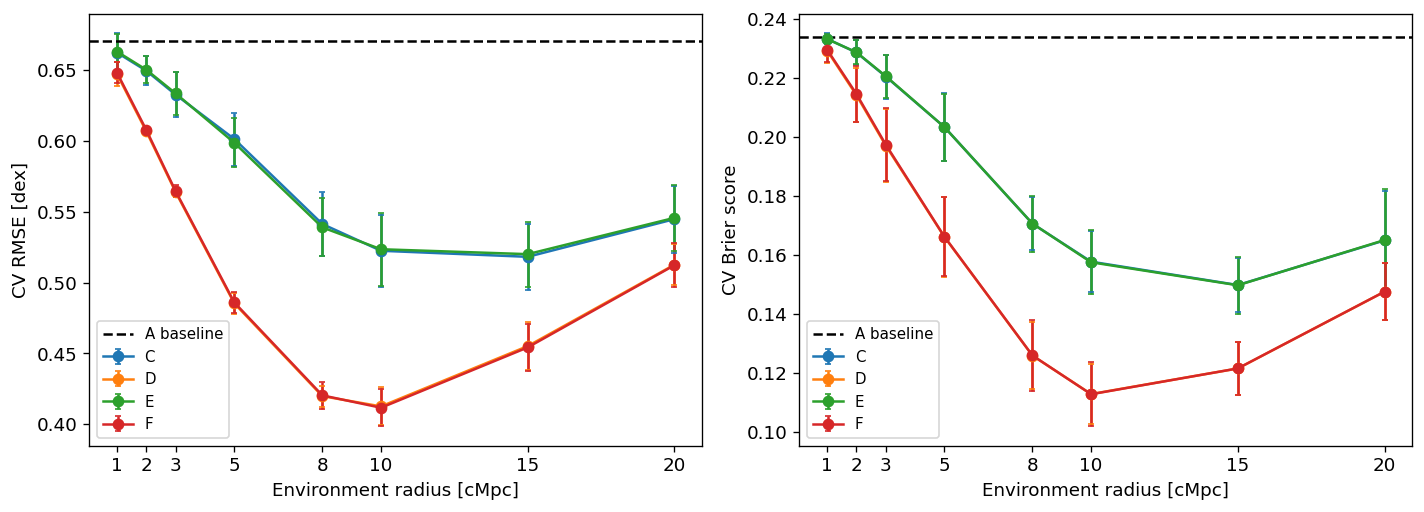

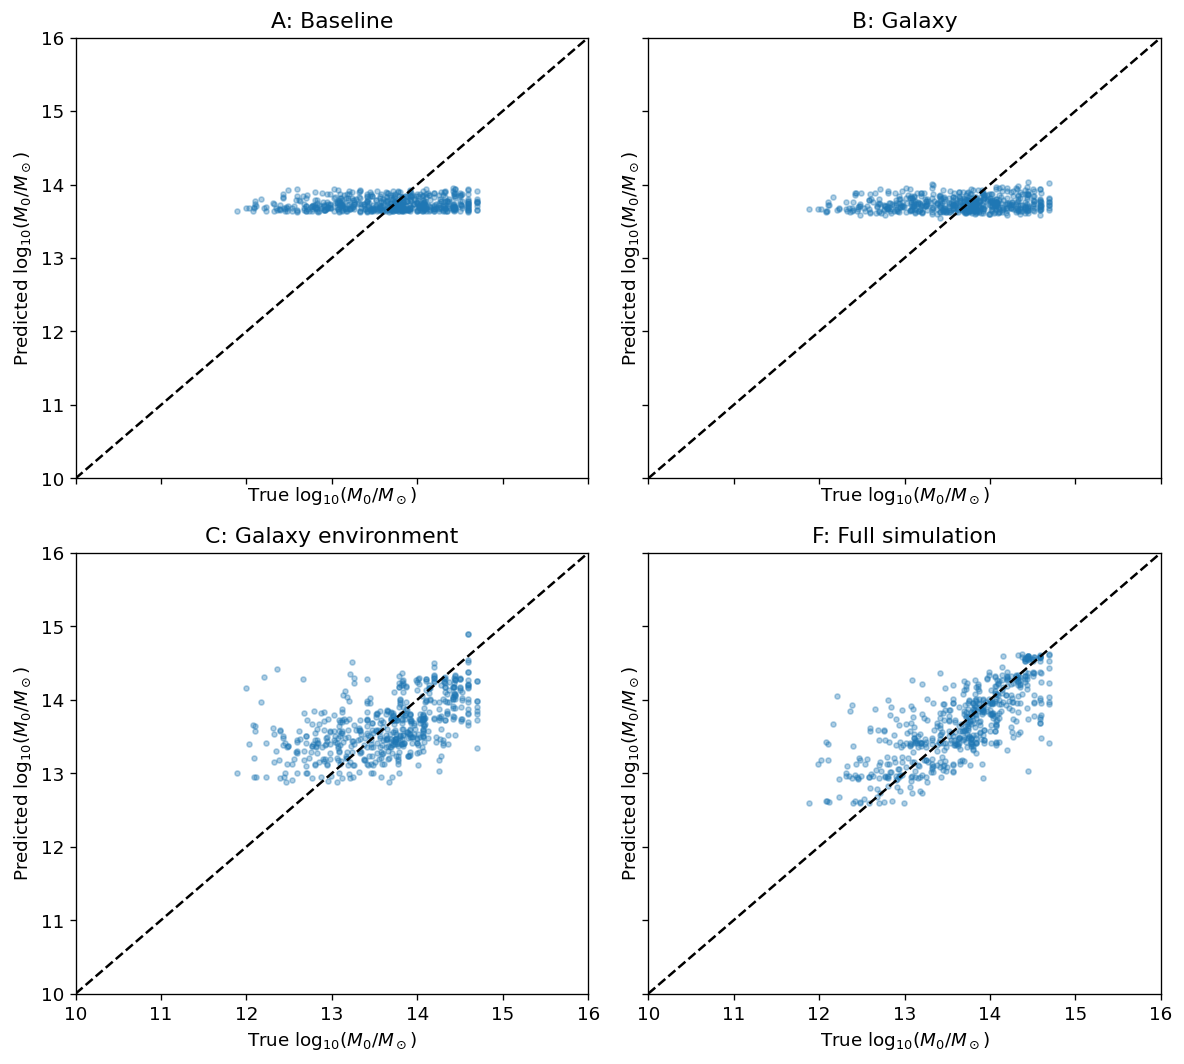

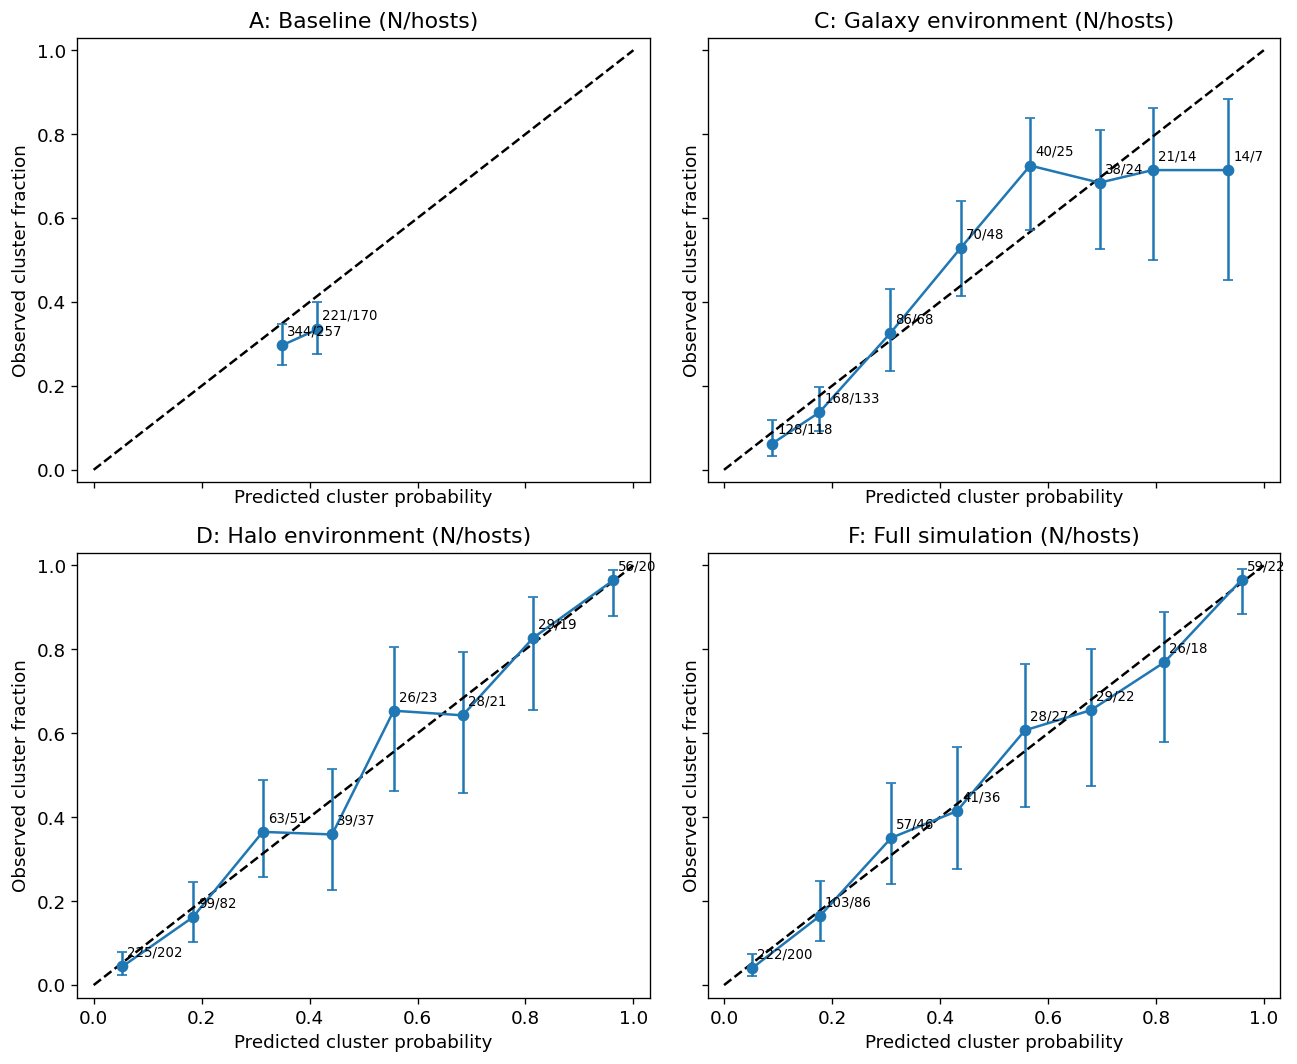

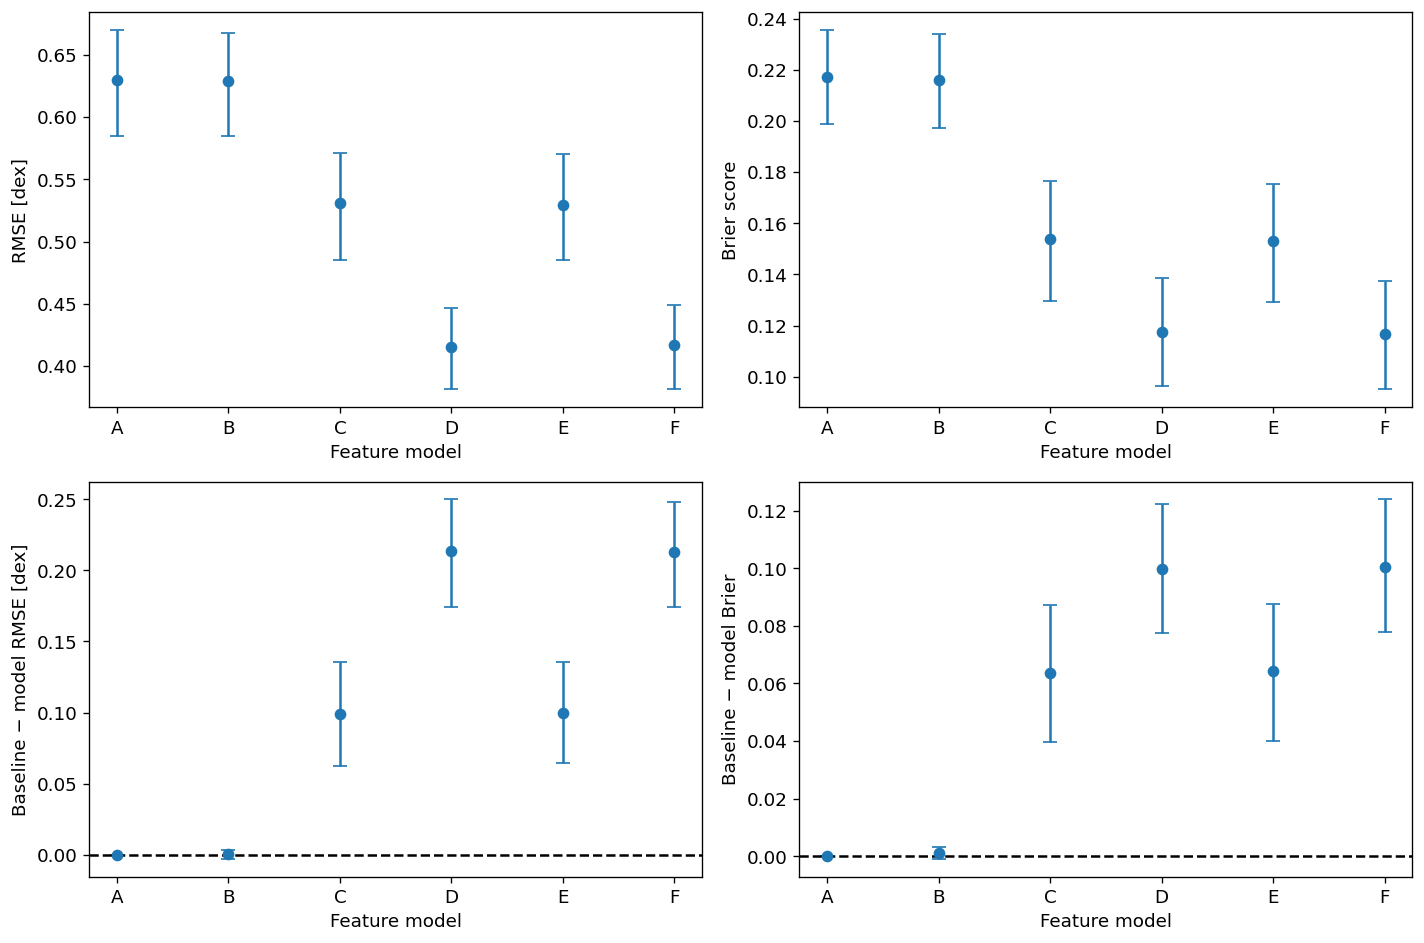

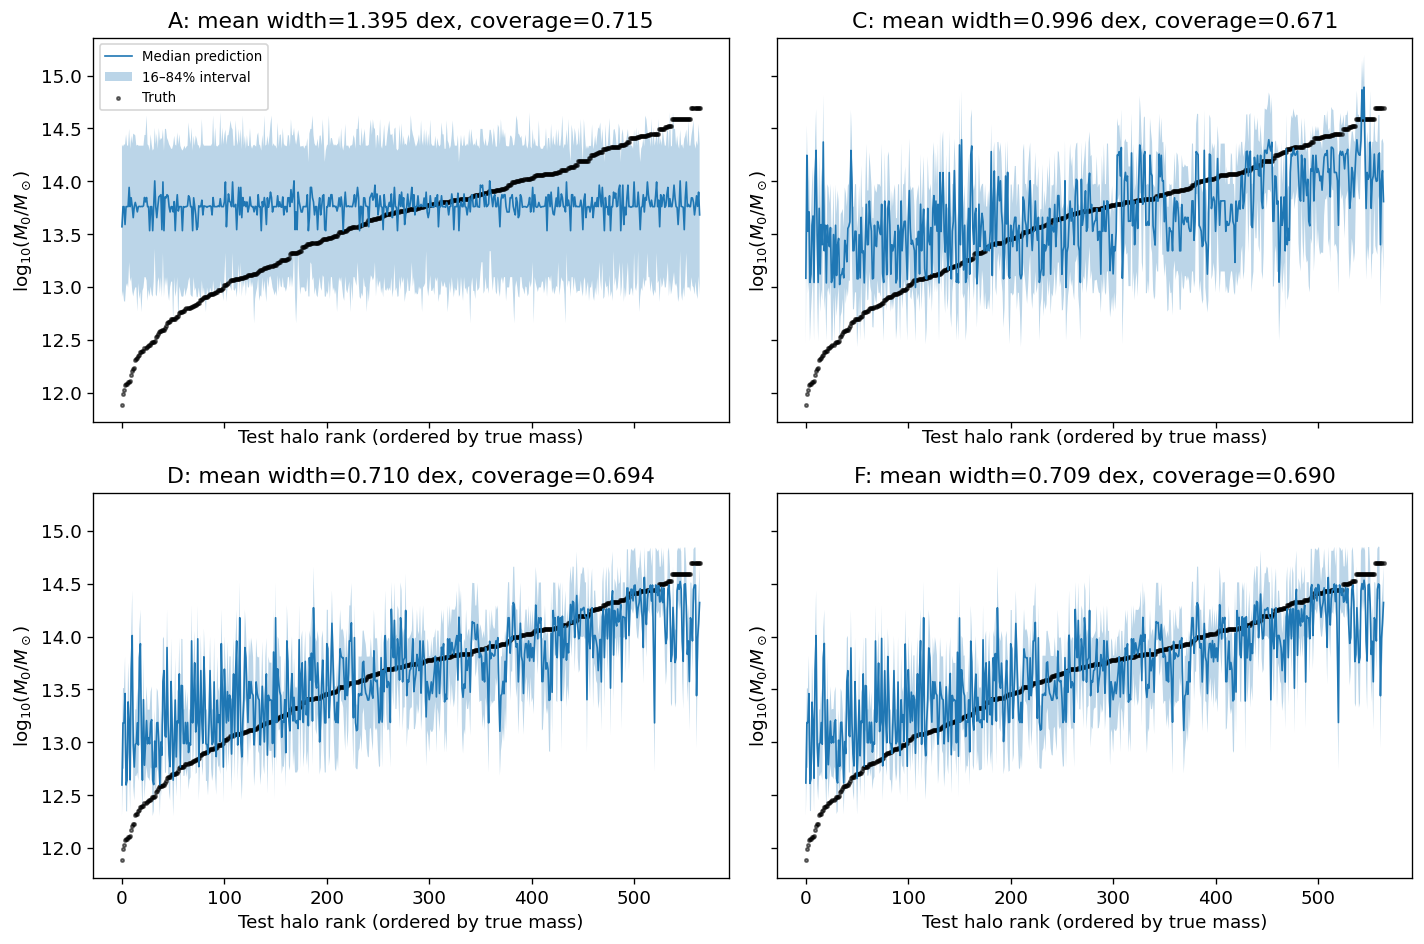

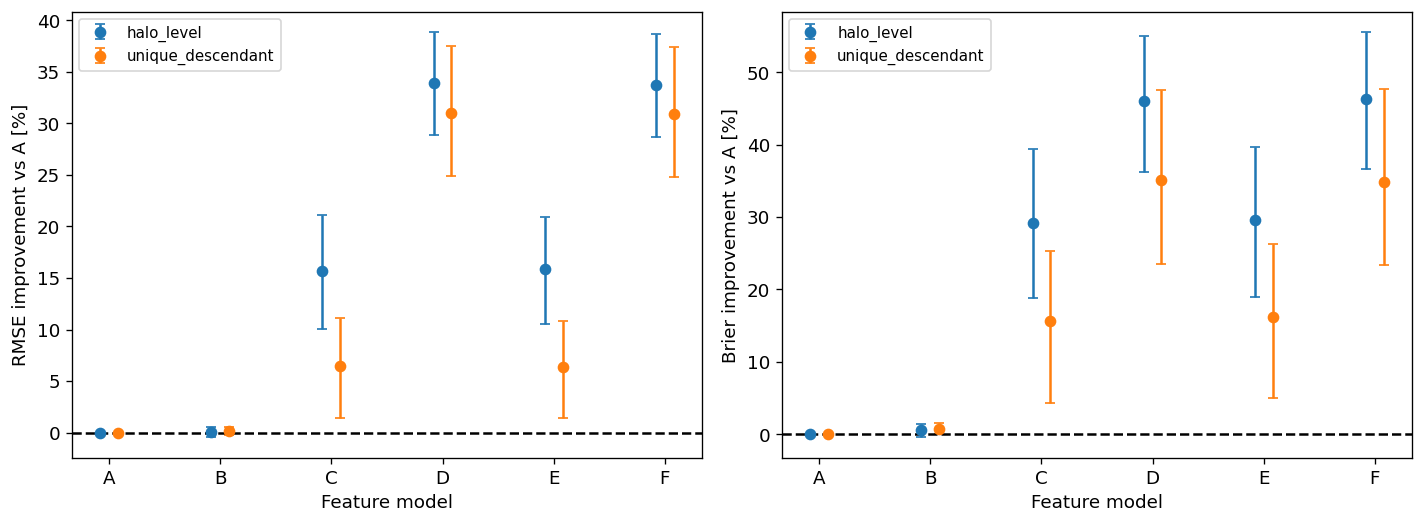

In [7]:
def savefig(fig, name):
    fig.savefig(FIG_DIR / (name+'.png'), dpi=200, bbox_inches='tight')
    fig.savefig(FIG_DIR / (name+'.svg'), bbox_inches='tight')
    plt.show()
    plt.close(fig)

# Fig.1: per-radius best training-CV candidate; selection within each radius.
fig, axes = plt.subplots(1,2,figsize=(12,4.4))
main_cv = cv_table[cv_table['sample'].eq('halo_level')]
for ax, task, ylabel in zip(axes, ['regression','classification'], ['CV RMSE [dex]','CV Brier score']):
    for key in ['C','D','E','F']:
        table = main_cv[main_cv.model.eq(key)&main_cv.task.eq(task)]
        rows=[]
        for radius in RADII:
            stats=table[table.radius.eq(radius)].groupby('family').loss.agg(['mean','std'])
            best=stats.loc[stats['mean'].idxmin()]
            rows.append((best['mean'],best['std']))
        rows=np.array(rows)
        ax.errorbar(RADII,rows[:,0],yerr=rows[:,1],marker='o',capsize=2,label=key)
    ax.axhline(selected['halo_level']['A'][task]['cv_score'],color='k',ls='--',label='A baseline')
    ax.set(xlabel='Environment radius [cMpc]',ylabel=ylabel,xticks=RADII)
    ax.legend(fontsize=9)
fig.tight_layout(); savefig(fig,'fig1_radius_cv')

preds = all_predictions['halo_level']; truth=preds.logM200c_z0.to_numpy()
fig,axes=plt.subplots(2,2,figsize=(10,9),sharex=True,sharey=True)
lo=np.floor(min(truth.min(),min(preds[f'pred_logM0_{k}'].min() for k in MODEL_NAMES))*.5)*2
hi=np.ceil(max(truth.max(),max(preds[f'pred_logM0_{k}'].max() for k in MODEL_NAMES))*.5)*2
for ax,key in zip(axes.ravel(),['A','B','C','F']):
    ax.scatter(truth,preds[f'pred_logM0_{key}'],s=9,alpha=.35,rasterized=True)
    ax.plot([lo,hi],[lo,hi],'k--'); ax.set(xlim=(lo,hi),ylim=(lo,hi),title=f'{key}: {MODEL_NAMES[key]}',
        xlabel=r'True $\log_{10}(M_0/M_\odot)$',ylabel=r'Predicted $\log_{10}(M_0/M_\odot)$')
fig.tight_layout(); savefig(fig,'fig2_true_predicted')

calibration_rows=[]
rng=np.random.RandomState(RANDOM_SEED+1)
for sample,frame in all_predictions.items():
    host_ids=frame.GroupID_z0.to_numpy(); hosts=np.unique(host_ids)
    # Same whole-test host resamples for every bin/model.
    host_weights=np.array([np.bincount(rng.randint(0,len(hosts),len(hosts)),minlength=len(hosts)) for _ in range(BOOTSTRAP_N)])
    for key in MODEL_NAMES:
        prob=frame[f'p_cluster_{key}'].to_numpy(); target=frame.cluster.to_numpy()
        bin_index=np.clip(np.searchsorted(CALIBRATION_EDGES,prob,side='right')-1,0,len(CALIBRATION_EDGES)-2)
        for j in range(len(CALIBRATION_EDGES)-1):
            mask=bin_index==j; count=mask.sum()
            if count==0: continue
            rate=target[mask].mean(); z=1.959963984540054
            center=(rate+z*z/(2*count))/(1+z*z/count)
            half=z*np.sqrt(rate*(1-rate)/count+z*z/(4*count*count))/(1+z*z/count)
            ng=np.array([np.sum(mask&(host_ids==g)) for g in hosts])
            pos=np.array([np.sum(mask&(host_ids==g)&(target==1)) for g in hosts])
            denom=host_weights@ng; numerator=host_weights@pos
            boot_rate=numerator[denom>0]/denom[denom>0]
            cilo,cihi=np.percentile(boot_rate,[2.5,97.5])
            calibration_rows.append(dict(sample=sample,model=key,bin=j,left=CALIBRATION_EDGES[j],right=CALIBRATION_EDGES[j+1],
                predicted_mean=prob[mask].mean(),cluster_fraction=rate,N=int(count),N_hosts=len(np.unique(host_ids[mask])),
                wilson_lo=center-half,wilson_hi=center+half,host_bootstrap_lo=cilo,host_bootstrap_hi=cihi))
calibration=pd.DataFrame(calibration_rows); calibration.to_csv(OUTPUT_DIR/'calibration_bins.csv',index=False)
fig,axes=plt.subplots(2,2,figsize=(11,9),sharex=True,sharey=True)
for ax,key in zip(axes.ravel(),['A','C','D','F']):
    tab=calibration[calibration['sample'].eq('halo_level')&calibration.model.eq(key)]
    ax.plot([0,1],[0,1],'k--')
    ax.errorbar(tab.predicted_mean,tab.cluster_fraction,
        yerr=np.vstack([tab.cluster_fraction-tab.wilson_lo,tab.wilson_hi-tab.cluster_fraction]),fmt='o-',capsize=3)
    for row in tab.itertuples():
        ax.annotate(f'{row.N}/{row.N_hosts}',(row.predicted_mean,row.cluster_fraction),xytext=(3,6),textcoords='offset points',fontsize=8)
    ax.set(xlim=(-.03,1.03),ylim=(-.03,1.03),title=f'{key}: {MODEL_NAMES[key]} (N/hosts)',
           xlabel='Predicted cluster probability',ylabel='Observed cluster fraction')
fig.tight_layout(); savefig(fig,'fig3_calibration')

main=comparison[comparison['sample'].eq('halo_level')].set_index('model').loc[list(MODEL_NAMES)]
fig,axes=plt.subplots(2,2,figsize=(12,8))
for col,metric in enumerate(['RMSE','Brier']):
    y=main[metric].to_numpy(); intervals=main[[metric+'_lo',metric+'_hi']].to_numpy()
    axes[0,col].errorbar(np.arange(6),y,yerr=np.abs(np.vstack([y-intervals[:,0],intervals[:,1]-y])),fmt='o',capsize=4)
    y=main['Delta_'+metric].to_numpy(); intervals=main[['Delta_'+metric+'_lo','Delta_'+metric+'_hi']].to_numpy()
    axes[1,col].errorbar(np.arange(6),y,yerr=np.abs(np.vstack([y-intervals[:,0],intervals[:,1]-y])),fmt='o',capsize=4)
    axes[1,col].axhline(0,color='k',ls='--')
    axes[0,col].set_ylabel(metric+(' [dex]' if metric=='RMSE' else ' score'))
    axes[1,col].set_ylabel('Baseline − model '+metric+(' [dex]' if metric=='RMSE' else ''))
for ax in axes.ravel(): ax.set(xticks=np.arange(6),xticklabels=list(MODEL_NAMES),xlabel='Feature model')
fig.tight_layout(); savefig(fig,'fig4_model_comparison')

fig,axes=plt.subplots(2,2,figsize=(12,8),sharex=True,sharey=True)
order=np.argsort(truth); x=np.arange(len(truth))
for ax,key in zip(axes.ravel(),['A','C','D','F']):
    ax.fill_between(x,preds[f'Q16_{key}'].to_numpy()[order],preds[f'Q84_{key}'].to_numpy()[order],alpha=.3,label='16–84% interval')
    ax.plot(x,preds[f'Q50_{key}'].to_numpy()[order],lw=1,label='Median prediction')
    ax.scatter(x,truth[order],s=4,c='k',alpha=.5,label='Truth',rasterized=True)
    row=main.loc[key]
    ax.set(title=f'{key}: mean width={row.W68:.3f} dex, coverage={row.Coverage:.3f}',
           xlabel='Test halo rank (ordered by true mass)',ylabel=r'$\log_{10}(M_0/M_\odot)$')
axes[0,0].legend(fontsize=8); fig.tight_layout(); savefig(fig,'fig5_intervals')

fig,axes=plt.subplots(1,2,figsize=(12,4.5))
for ax,metric in zip(axes,['RMSE','Brier']):
    for offset,sample,color in [(-.08,'halo_level','tab:blue'),(.08,'unique_descendant','tab:orange')]:
        if sample not in all_predictions: continue
        tab=comparison[comparison['sample'].eq(sample)].set_index('model').loc[list(MODEL_NAMES)]
        y=tab[metric+'_improvement_pct'].to_numpy(); lo=tab[metric+'_improvement_pct_lo'].to_numpy(); hi=tab[metric+'_improvement_pct_hi'].to_numpy()
        ax.errorbar(np.arange(6)+offset,y,yerr=np.abs(np.vstack([y-lo,hi-y])),fmt='o',capsize=3,label=sample,color=color)
    ax.axhline(0,color='k',ls='--'); ax.set(xticks=np.arange(6),xticklabels=list(MODEL_NAMES),xlabel='Feature model',ylabel=metric+' improvement vs A [%]'); ax.legend(fontsize=9)
fig.tight_layout(); savefig(fig,'fig6_improvement')


## 保存・数値に基づくsummary

主要な結論はhalo-levelを使用する。改善量のCIが0を跨ぐ場合は明確な改善と結論しない。確率の信頼性はBrier単独では断定せず、calibrationと各binの標本数を確認する。testでの診断をもとにモデルを変更する場合は新たな評価サンプルが必要となる。

In [8]:
def json_safe(value):
    if isinstance(value, dict): return {str(k):json_safe(v) for k,v in value.items()}
    if isinstance(value,(list,tuple)): return [json_safe(v) for v in value]
    if isinstance(value,np.generic): return value.item()
    if isinstance(value,Path): return str(value)
    return value
(OUTPUT_DIR/'selected_features.json').write_text(json.dumps(json_safe(selected),indent=2,ensure_ascii=False))
metadata = dict(random_seed=RANDOM_SEED,test_size=TEST_SIZE,cv_folds=CV_FOLDS,bootstrap_n=BOOTSTRAP_N,
    split_method='GroupShuffleSplit(GroupID_z0)', tuning='GroupKFold on training hosts only',
    bootstrap_unit='test GroupID_z0; paired across models', calibration='raw classifier probabilities; no post-hoc recalibration',
    sample_selection='10.8 < logM200c_z8 < 11.2; finite IDs and target; nonnegative host IDs',
    inputs={str(p):{'sha256':hashlib.sha256(p.read_bytes()).hexdigest()} for p in [DESCENDANT_PATH,ENVIRONMENT_PATH]},
    selected_models=selected, algorithm_selections=algorithm_selections, versions=dict(python=platform.python_version(),numpy=np.__version__,pandas=pd.__version__,
    scipy=scipy.__version__,sklearn=sklearn.__version__),
    elapsed_seconds=time.time()-START_TIME, output_dir=str(OUTPUT_DIR),
    samples={sample:dict(N_train=len(tr),N_test=len(te),N_train_hosts=tr.GroupID_z0.nunique(),N_test_hosts=te.GroupID_z0.nunique(),
        train_GroupID_z8=tr.GroupID_z8.tolist(),test_GroupID_z8=te.GroupID_z8.tolist(),
        train_GroupID_z0=sorted(tr.GroupID_z0.unique().tolist()),test_GroupID_z0=sorted(te.GroupID_z0.unique().tolist()),
        hosts_disjoint=set(tr.GroupID_z0).isdisjoint(set(te.GroupID_z0))) for sample,(tr,te) in splits.items()})
(OUTPUT_DIR/'run_metadata.json').write_text(json.dumps(json_safe(metadata),indent=2,ensure_ascii=False))
lines=['### 自動計算summary（halo-level、95% paired host-bootstrap CI）',
       f"A baseline: RMSE **{main.loc['A','RMSE']:.3f} dex**, Brier **{main.loc['A','Brier']:.4f}**。"]
for key in ['B','C','D','E','F']:
    r=main.loc[key]
    radius_reg = '対象外' if pd.isna(r.regression_radius) else f'{r.regression_radius:g}'
    radius_clf = '対象外' if pd.isna(r.classification_radius) else f'{r.classification_radius:g}'
    lines.append(f"- {key} {MODEL_NAMES[key]}: RMSE {r.RMSE:.3f} dex; 改善率 {r.RMSE_improvement_pct:.1f}% [{r.RMSE_improvement_pct_lo:.1f}, {r.RMSE_improvement_pct_hi:.1f}]。Brier {r.Brier:.4f}; 改善率 {r.Brier_improvement_pct:.1f}% [{r.Brier_improvement_pct_lo:.1f}, {r.Brier_improvement_pct_hi:.1f}]。回帰/分類半径 {radius_reg}/{radius_clf} cMpc。区間幅 {r.W68:.3f} dex [{r.W68_lo:.3f}, {r.W68_hi:.3f}]、coverage {r.Coverage:.3f} [{r.Coverage_lo:.3f}, {r.Coverage_hi:.3f}]。")
lines.append(f"Aの区間幅 {main.loc['A','W68']:.3f} dex、coverage {main.loc['A','Coverage']:.3f}。名目coverageは0.68で、幅の縮小だけを成功とみなさない。")
for key in ['C','D']:
    r=main.loc[key]
    conclusion='改善のCIは正' if r.Delta_RMSE_lo>0 else '明確な改善は未確定'
    probability='改善のCIは正' if r.Delta_Brier_lo>0 else '明確な改善は未確定'
    lines.append(f'{key}: test RMSEについて{conclusion}、Brierについて{probability}。')
lines.append('training/testの最終ホスト共有はassertで0を確認した。unique-descendantとの比較はmodel_comparisonとFig.6を参照。異なるホスト間の空間相関、単一simulation volume、モデル選択の変動は残る。')
for key in ['A','C','D','F']:
    tab = calibration[calibration['sample'].eq('halo_level') & calibration.model.eq(key)]
    well_populated = tab[tab.N.ge(30)]
    outside = ((well_populated.predicted_mean < well_populated.host_bootstrap_lo) |
               (well_populated.predicted_mean > well_populated.host_bootstrap_hi)).sum()
    ece = np.sum(tab.N * np.abs(tab.predicted_mean-tab.cluster_fraction))/tab.N.sum()
    lines.append(f'{key} calibration: binned ECE={ece:.3f}。N≥30の{len(well_populated)} bin中、平均予測確率が観測率のhost-bootstrap 95% CI外にあるbinは{outside}。これは多重比較を補正しない診断で、完全なcalibrationを証明する検定ではない。')
lines.append('unique-descendantのcoverageは主sampleと別に確認する。観測selectionの変化によって区間の較正も変わり得る。')
lines.append('Cluster確率の信頼性はFig.3とcalibration_bins.csvの観測率・CI・標本数から評価する。Brierの改善は完全なcalibrationを保証しない。Mock JWSTへの拡張には、halo mass proxyの誤差、観測selection、不完全性、恒星質量/SFRの推定誤差、投影・photo-z効果を取り入れ、Nhalo benchmarkを観測可能量と区別した再検証が必要。')
summary_text='\n\n'.join(lines)
display(Markdown(summary_text))
(OUTPUT_DIR/'summary.md').write_text(summary_text)
print('Saved results:',OUTPUT_DIR)


Saved results: /Users/clab/research/tng-work/protohalo/analysis_summary/descendant_predictive_performance


### 自動計算summary（halo-level、95% paired host-bootstrap CI）

A baseline: RMSE **0.629 dex**, Brier **0.2172**。

- B Galaxy: RMSE 0.629 dex; 改善率 0.0% [-0.5, 0.5]。Brier 0.2160; 改善率 0.6% [-0.4, 1.4]。回帰/分類半径 対象外/対象外 cMpc。区間幅 1.379 dex [1.371, 1.388]、coverage 0.692 [0.635, 0.755]。

- C Galaxy environment: RMSE 0.531 dex; 改善率 15.7% [10.1, 21.1]。Brier 0.1537; 改善率 29.2% [18.8, 39.4]。回帰/分類半径 15/15 cMpc。区間幅 0.996 dex [0.978, 1.014]、coverage 0.671 [0.617, 0.723]。

- D Halo environment: RMSE 0.416 dex; 改善率 34.0% [28.8, 38.9]。Brier 0.1174; 改善率 46.0% [36.2, 55.0]。回帰/分類半径 10/10 cMpc。区間幅 0.710 dex [0.696, 0.723]、coverage 0.694 [0.648, 0.740]。

- E Galaxy + environment: RMSE 0.530 dex; 改善率 15.8% [10.5, 20.9]。Brier 0.1530; 改善率 29.6% [19.0, 39.7]。回帰/分類半径 15/15 cMpc。区間幅 0.995 dex [0.977, 1.012]、coverage 0.662 [0.607, 0.714]。

- F Full simulation: RMSE 0.417 dex; 改善率 33.8% [28.7, 38.6]。Brier 0.1167; 改善率 46.3% [36.6, 55.6]。回帰/分類半径 10/10 cMpc。区間幅 0.709 dex [0.695, 0.722]、coverage 0.690 [0.647, 0.738]。

Aの区間幅 1.395 dex、coverage 0.715。名目coverageは0.68で、幅の縮小だけを成功とみなさない。

C: test RMSEについて改善のCIは正、Brierについて改善のCIは正。

D: test RMSEについて改善のCIは正、Brierについて改善のCIは正。

training/testの最終ホスト共有はassertで0を確認した。unique-descendantとの比較はmodel_comparisonとFig.6を参照。異なるホスト間の空間相関、単一simulation volume、モデル選択の変動は残る。

A calibration: binned ECE=0.063。N≥30の2 bin中、平均予測確率が観測率のhost-bootstrap 95% CI外にあるbinは0。これは多重比較を補正しない診断で、完全なcalibrationを証明する検定ではない。

C calibration: binned ECE=0.052。N≥30の6 bin中、平均予測確率が観測率のhost-bootstrap 95% CI外にあるbinは0。これは多重比較を補正しない診断で、完全なcalibrationを証明する検定ではない。

D calibration: binned ECE=0.026。N≥30の5 bin中、平均予測確率が観測率のhost-bootstrap 95% CI外にあるbinは0。これは多重比較を補正しない診断で、完全なcalibrationを証明する検定ではない。

F calibration: binned ECE=0.019。N≥30の5 bin中、平均予測確率が観測率のhost-bootstrap 95% CI外にあるbinは0。これは多重比較を補正しない診断で、完全なcalibrationを証明する検定ではない。

unique-descendantのcoverageは主sampleと別に確認する。観測selectionの変化によって区間の較正も変わり得る。

Cluster確率の信頼性はFig.3とcalibration_bins.csvの観測率・CI・標本数から評価する。Brierの改善は完全なcalibrationを保証しない。Mock JWSTへの拡張には、halo mass proxyの誤差、観測selection、不完全性、恒星質量/SFRの推定誤差、投影・photo-z効果を取り入れ、Nhalo benchmarkを観測可能量と区別した再検証が必要。